In [ ]:
import os
import tensorflow as tf

num_skipped = 0
# Path to your dataset directory
data_dir = '/content/PetImages'

print("Scanning for corrupt images...")
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join(data_dir, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            # Verify if the image has a valid JPEG/PNG encoding header
            is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete the corrupt file
            os.remove(fpath)

print(f"Clean up complete. Deleted {num_skipped} corrupt images.")

Scanning for corrupt images...
Clean up complete. Deleted 499 corrupt images.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
DATA_DIR = '/content/PetImages'

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/PetImages'

In [2]:
# Define the CNN architecture
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Start training
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

# Save the trained model for deployment
model.save('model_hewan.h5')

NameError: name 'models' is not defined

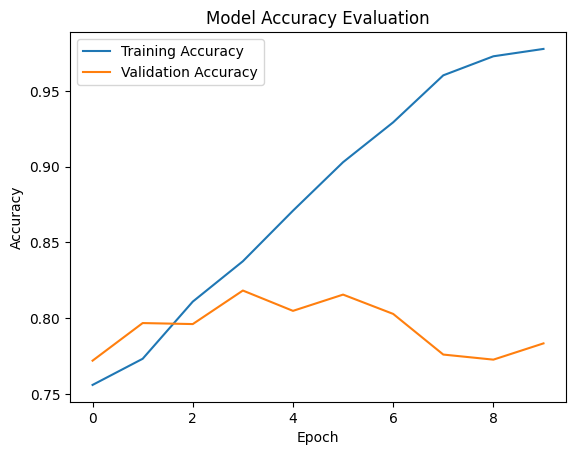

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
%%bash
# 1. Define your credentials as bash variables
HF_USERNAME="YOUR USERNAME"
HF_SPACE_NAME="YOUR SPACE NAME"

# 2. Clone the repository using authenticated URL
git clone https://huggingface.co/spaces/$HF_USERNAME/$HF_SPACE_NAME

# 3. Move your trained model into the cloned directory
mv model_hewan.h5 $HF_SPACE_NAME/

Cloning into 'pet-prediction-cnn'...


In [ ]:
import os

# Set your exact space folder name
repo_dir = 'pet-prediction-cnn'

# Create requirements.txt
with open(os.path.join(repo_dir, 'requirements.txt'), 'w') as f:
    f.write("tensorflow\ngradio\nnumpy\npillow")

# Create app.py with clean English comments
app_code = """import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model('model_hewan.h5')
labels = ['Cat', 'Dog']

def predict_image(image):
    image = image.resize((128, 128))
    img_array = tf.keras.preprocessing.image.img_to_array(image)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    predicted_class = labels[1] if prediction[0][0] > 0.5 else labels[0]
    return f"Prediction: {predicted_class}"

# Build Gradio interface
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Cat vs Dog Classifier 🐱🐶",
    description="Upload an image to predict whether it is a Cat or a Dog."
)

interface.launch()
"""

with open(os.path.join(repo_dir, 'app.py'), 'w') as f:
    f.write(app_code)

print("Deployment files successfully created inside 'pet-prediction-cnn'!")

Deployment files successfully created inside 'pet-prediction-cnn'!


In [ ]:
%%bash
# 1. Change directory to your space folder
cd pet-prediction-cnn

# 2. Configure git credentials for this session
git config --global user.email "YOUR EMAIL"
git config --global user.name "YOUR USERNAME"

# 3. Explicitly set the remote URL to include your write token
git remote set-url origin YOUR HUGGING FACE SPACE URL

# 4. Track, commit, and upload the files
git add .
git commit -m "Deploy CNN model with Gradio via Colab" --allow-empty
git push -u origin main

[main b4cf220] Deploy CNN model with Gradio via Colab
Uploading LFS objects: 100% (1/1), 44 MB | 0 B/s, done.
Branch 'main' set up to track remote branch 'main' from 'origin'.


To https://huggingface.co/spaces/brilliannaufal06/pet-prediction-cnn
   67b7432..b4cf220  main -> main
